# Notebook 2: depositing a field to a Cartesian grid

In [1]:
import paicos as pa
import numpy as np
import turbocluster as tc
%matplotlib widget

pa.settings.strict_units = False

# A snapshot object
snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output', 
                   305, basename='snapshot')
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([500., 500., 500.], dtype=float)


In [2]:
npix = 256

In [11]:
depo_NGP = tc.DepositCartesianGrid(snap, center, widths, npix=npix, 
                                   threadsperblock=256, 
                                   regionType='cartesian', kernel_type='NGP')

density_cartesian_NGP = depo_NGP.deposit_variable('0_Density', weight='0_Volume')

# del depo_NGP

No `pos' argument given. Defaults to gas particles
No `hsml' argument given. Defaults to gas particles


In [3]:
depo_CIC = tc.DepositCartesianGrid(snap, center, widths, npix=npix, 
                                   threadsperblock=256, 
                                   regionType='cartesian', kernel_type='CIC')

npoints = depo_CIC.npoints

density_cartesian_CIC = depo_CIC.deposit_variable('0_Density', weight='0_Volume')

# del depo_CIC

No `pos' argument given. Defaults to gas particles
No `hsml' argument given. Defaults to gas particles
Attempting to get derived variable: 0_Volume...	[DONE]



In [12]:
depo_TSC = tc.DepositCartesianGrid(snap, center, widths, npix=npix, 
                                   threadsperblock=256, 
                                   regionType='cartesian', kernel_type="TSC",
                                   orientation=None)

density_cartesian_TSC = depo_TSC.deposit_variable(snap['0_Density'], weight='0_Volume')

# del depo_TSC

No `pos' argument given. Defaults to gas particles
No `hsml' argument given. Defaults to gas particles


In [13]:
depo_PCS = tc.DepositCartesianGrid(snap, center, widths, npix=npix, 
                                   threadsperblock=256, 
                                   regionType='cartesian', kernel_type="PCS")

density_cartesian_PCS = depo_PCS.deposit_variable('0_Density', weight='0_Volume')

# del depo_PCS

No `pos' argument given. Defaults to gas particles
No `hsml' argument given. Defaults to gas particles


In [15]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

widths_slicer = widths.copy()
widths_slicer[2] = 0.
slicer = pa.Slicer(snap, center, widths_slicer, 'z', npix=npix+1)
extent = slicer.centered_extent.to('Mpc')

Text(0.5, 0.95, 'Density field (voronoi and cartesian)')

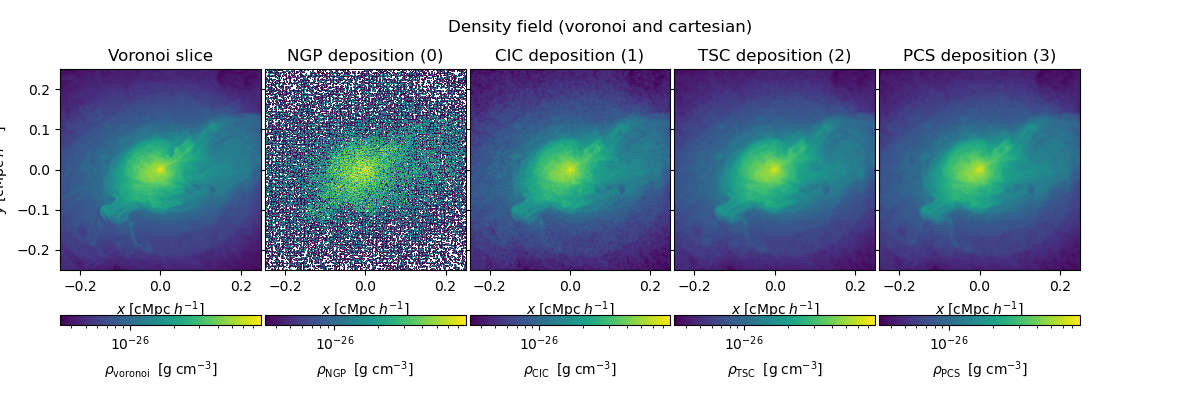

In [37]:


dens_voro = slicer.slice_variable('0_Density')
""" 
I am not sure why here I need to transpose to make sure
the alignment is the same as the slice
""" 
dens_cart_NGP = (density_cartesian_NGP[:,:,int(npoints[2]//2)-1].T).to_physical.cgs
dens_cart_CIC = (density_cartesian_CIC[:,:,int(npoints[2]//2)-1].T).to_physical.cgs
dens_cart_TSC = (density_cartesian_TSC[:,:,int(npoints[2]//2)-1].T).to_physical.cgs
dens_cart_PCS = (density_cartesian_PCS[:,:,int(npoints[2]//2)-1].T).to_physical.cgs
# dens_bulk = slicer.slice_variable(smoothVar)
# dens_turb = slicer.slice_variable(relativeTurbVar)

dens_voro = dens_voro.to_physical.cgs

vmin = np.min(dens_voro.value)
vmax = np.max(dens_voro.value)
norm = LogNorm(vmin=vmin,vmax=vmax)

fig, axes = plt.subplots(1,5, figsize=(12,4),sharex=True, sharey=True)

im1 = axes[0].imshow(
    dens_voro.value, origin='lower', norm=norm,extent=extent.value)

im2 = axes[1].imshow(
    dens_cart_NGP.value, origin='lower', norm=norm,extent=extent.value)

im3 = axes[2].imshow(
    dens_cart_CIC.value, origin='lower', norm=norm,extent=extent.value)

im4 = axes[3].imshow(
    dens_cart_TSC.value, origin='lower', norm=norm,extent=extent.value)

im5 = axes[4].imshow(
    dens_cart_PCS.value, origin='lower', norm=norm,extent=extent.value)


axes[0].set_title('Voronoi slice')
axes[1].set_title('NGP deposition (0)')
axes[2].set_title('CIC deposition (1)')
axes[3].set_title('TSC deposition (2)')
axes[4].set_title('PCS deposition (3)')


for i in range(5):
    axes[i].set_xlabel(extent.label('x'))

axes[0].set_ylabel(extent.label('y'))



cbar = fig.colorbar(im1, orientation='horizontal')
cbar.set_label(dens_voro.label('\\rho_{\mathrm{voronoi}}'))

cbar = fig.colorbar(im2, orientation='horizontal')
cbar.set_label(dens_cart_NGP.label('\\rho_{\mathrm{NGP}}'))

cbar = fig.colorbar(im3, orientation='horizontal')
cbar.set_label(dens_cart_CIC.label('\\rho_{\mathrm{CIC}}'))

cbar = fig.colorbar(im4, orientation='horizontal')
cbar.set_label(dens_cart_TSC.label('\\rho_{\mathrm{TSC}}'))

cbar = fig.colorbar(im5, orientation='horizontal')
cbar.set_label(dens_cart_PCS.label('\\rho_{\mathrm{PCS}}'))


fig.subplots_adjust(top=0.85,
bottom=0.1,
left=0.05,
right=0.90,
hspace=0.0,
wspace=0.02)

fig.suptitle('Density field (voronoi and cartesian)',y=0.95)
# plt.savefig('deposit_comparison.pdf',dpi=400)
# plt.close()